### Код для локального сервера

In [1]:
import numpy as np
import pandas as pd
pd.set_option("display.max_colwidth", None)
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import OrdinalEncoder
import torch
from torch import nn
import torch.functional as F
from torch.utils.data import DataLoader, Subset, random_split

from torchvision.transforms import InterpolationMode
from torchvision import models
from torchvision.datasets import VisionDataset
from torchvision.transforms import ToTensor, Resize, Normalize, Compose, RandomResizedCrop, ColorJitter, RandomHorizontalFlip, RandomPerspective, RandomRotation, InterpolationMode, RandomApply, GaussianBlur

import random
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split

from PIL import Image

from tqdm import tqdm
import re

import os
import requests

import warnings
warnings.filterwarnings("ignore")

In [ ]:
root_dir = "data"
img_dir = "images"
csv_path = "good_atomic_no_noise_less_noresident.csv"

In [ ]:
def get_idx_row_from_image(img_name, data):
    (id, img_num) = img_name.split(".")[0].split("_")
    id = int(id)
    img_num = int(img_num)
    series = data[(data["ID"] == id) & (data["img_num"] == img_num)]
    idx = series.index[0]
    row = series.iloc[0]

    return (idx, row)

In [ ]:
class Attr(VisionDataset):
    def __init__(self, root_dir, img_dir, csv_path, transform=None):
        self.root_dir = root_dir
        self.img_dir = img_dir
        self.csv_path = csv_path

        super().__init__(self.root_dir, transform=transform)

        self.transform = transform

        self.image_paths = []
        self.labels = []
        self.orig_indices = []

        self._build_dataset()

    def _build_dataset(self):
        data = pd.read_csv(os.path.join(self.root_dir, self.csv_path))
        for img_name in os.listdir(os.path.join(self.root_dir, self.img_dir)):
            #idx = int(img_name.split('.')[0]) // old

            try:
                idx, row = get_idx_row_from_image(img_name, data)
            except:
                continue


            self.labels.append(row.attr_ind)
            self.orig_indices.append(idx)

            img_path = os.path.join(self.root_dir, self.img_dir, img_name)
            self.image_paths.append(img_path)

        print(f"Dataset loaded: {len(self.image_paths)} images")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [ ]:
default_transform = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)

ds = Attr(transform=default_transform, root_dir=root_dir, img_dir=img_dir, csv_path=csv_path)

Dataset loaded: 13931 images


In [ ]:
train_test_split = 0.9
train_val_split = 1
train_size = int(train_test_split * len(ds))
test_size = len(ds) - train_size
val_size = train_size - int(train_size * train_val_split)
train_size = int(train_size * train_val_split)

generator = torch.Generator().manual_seed(42)
train_ds, val_ds, test_ds = random_split(ds, [train_size, val_size, test_size], generator=generator)

#### Аугментации

In [ ]:
train_transform = Compose([
    RandomResizedCrop(
        size=(384, 384),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    RandomHorizontalFlip(p=0.5),

    ColorJitter(
        brightness=0.2,
        contrast=0.3,
        saturation=0.15,
        hue=0.05
    ),

    RandomApply([
        GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))
    ], p=0.2),

    RandomApply([
        RandomRotation(
            degrees=7,
            interpolation=InterpolationMode.BILINEAR
        )
    ], p=0.3),

    RandomApply([
        RandomPerspective(
            distortion_scale=0.15,
            p=1.0
        )
    ], p=0.2),

    ToTensor(),

    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

default_transform = Compose([
    Resize((384, 384)),
    ToTensor(),
    Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_ds.transform = train_transform

NameError: name 'train_ds' is not defined

#### Модельки

In [ ]:
def train_model(model, train_loader, val_loader, epochs, lr, do_val, weights=None):
    criterion = nn.CrossEntropyLoss()
    if weights is not None:
        criterion.weight = weights

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01, betas=(0.9, 0.999))

    history = {"train_loss": []}
    if do_val:
        history["val_acc"] = []

    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        print("Training:")
        for x, y in tqdm(train_loader):
            x = x.to(device)
            y = y.to(device).long()

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_loss = train_loss / len(train_loader)
        history["train_loss"].append(avg_loss)

        print(f"Epoch {epoch+1}/{epochs}:")
        print(f"  Train loss: {avg_loss:.4f}")

        if not do_val:
            continue

        model.eval()
        all_probs = []
        all_preds = []
        all_y = []

        print("Validation:")
        with torch.no_grad():
            for x, y in tqdm(val_loader):
                x = x.to(device)
                y = y.to(device).long()

                out = model(x)
                probs = torch.softmax(out, dim=1)
                preds = torch.argmax(probs, dim=1)

                all_probs.append(probs.cpu())
                all_preds.append(preds.cpu())
                all_y.append(y.cpu())

        all_probs = torch.cat(all_probs).numpy()
        all_preds = torch.cat(all_preds).numpy()
        all_y = torch.cat(all_y).numpy()

        val_acc = accuracy_score(all_y, all_preds)

        print(f"  Val acc: {val_acc:.4f}")

        history["val_acc"].append(val_acc)

    return history

In [ ]:
model = models.swin_s(weights="Swin_S_Weights.DEFAULT")

for p in model.parameters():
    p.requires_grad = False

model.head = nn.Linear(model.head.in_features, 9, bias=True)

In [ ]:
model.modules

<bound method Module.modules of SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1

#### Треним

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
device

'cuda'

In [ ]:
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=3, lr=0.001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 196/196 [04:17<00:00,  1.32s/it]


Epoch 1/3:
  Train loss: 1.2524
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:28<00:00,  1.27s/it]


  Val acc: 0.5696
  Val micro f1: 0.5696
  Val macro f1: 0.4336
  Val AUC (OvR, macro): 0.8922
Training:


...

  Val acc: 0.5976
  Val micro f1: 0.5976
  Val macro f1: 0.5195
  Val AUC (OvR, macro): 0.9056
Training:


100%|████████████████████████████████████████████████████████████████████████████████| 196/196 [04:06<00:00,  1.26s/it]


Epoch 3/3:
  Train loss: 0.9908
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:27<00:00,  1.24s/it]

  Val acc: 0.6112
  Val micro f1: 0.6112
  Val macro f1: 0.5492
  Val AUC (OvR, macro): 0.9113


In [ ]:
model.modules

<bound method Module.modules of SwinTransformer(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): Permute()
      (2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
    )
    (1): Sequential(
      (0): SwinTransformerBlock(
        (norm1): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (attn): ShiftedWindowAttention(
          (qkv): Linear(in_features=96, out_features=288, bias=True)
          (proj): Linear(in_features=96, out_features=96, bias=True)
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
        (norm2): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
        (mlp): MLP(
          (0): Linear(in_features=96, out_features=384, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=384, out_features=96, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (1

#### Тюним

батч поменьше

In [ ]:
for p in model.parameters():
    p.requires_grad = False

In [ ]:
for p in model.head.parameters():
    p.requires_grad = True

In [ ]:
for p in model.features[5][12:].parameters():
    p.requires_grad = True

In [ ]:
for p in model.norm.parameters():
    p.requires_grad = True
for p in model.features[6].parameters():
    p.requires_grad = True
for p in model.features[7].parameters():
    p.requires_grad = True

In [ ]:
k = 0
for p in model.parameters():
    if p.requires_grad:
        k += 1
k

215

In [ ]:
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(test_ds, batch_size=64, shuffle=False)

for p in model.norm.parameters():
    p.requires_grad = True
for p in model.features[6].parameters():
    p.requires_grad = True
for p in model.features[7].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.0005, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 392/392 [04:40<00:00,  1.40it/s]


Epoch 1/1:
  Train loss: 1.0078
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:27<00:00,  1.23s/it]

  Val acc: 0.6399
  Val micro f1: 0.6399
  Val macro f1: 0.5688
  Val AUC (OvR, macro): 0.9334


In [ ]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

for p in model.features[5][12:].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=2, lr=0.0001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 784/784 [04:33<00:00,  2.87it/s]


Epoch 1/2:
  Train loss: 0.7789
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:26<00:00,  1.22s/it]


  Val acc: 0.7131
  Val micro f1: 0.7131
  Val macro f1: 0.7141
  Val AUC (OvR, macro): 0.9479
Training:


 28%|██████████████████████▍                                                         | 220/784 [01:17<03:19,  2.83it/s]


KeyboardInterrupt: 

In [ ]:
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)

for p in model.features[5][4:].parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.00005, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 784/784 [05:12<00:00,  2.51it/s]


Epoch 1/1:
  Train loss: 0.5793
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:25<00:00,  1.17s/it]

  Val acc: 0.7195
  Val micro f1: 0.7195
  Val macro f1: 0.7108
  Val AUC (OvR, macro): 0.9567


In [ ]:
for p in model.parameters():
    p.requires_grad = True
hist = train_model(model, train_loader=train_loader, val_loader=val_loader, epochs=1, lr=0.00001, do_val=True)

Training:


100%|████████████████████████████████████████████████████████████████████████████████| 784/784 [06:24<00:00,  2.04it/s]


Epoch 1/1:
  Train loss: 0.3656
Validation:


100%|██████████████████████████████████████████████████████████████████████████████████| 22/22 [00:28<00:00,  1.28s/it]

  Val acc: 0.7346
  Val micro f1: 0.7346
  Val macro f1: 0.7190
  Val AUC (OvR, macro): 0.9579


#### Тестим

100%|██████████████████████████████████████████████████████████████████████████████████| 44/44 [00:26<00:00,  1.65it/s]

accuracy on class 0: 0.8250
accuracy on class 1: 0.7619
accuracy on class 2: 0.9000
accuracy on class 3: 0.5429
accuracy on class 4: 0.8983
accuracy on class 5: 0.6181
accuracy on class 6: 0.5804
accuracy on class 7: 0.7218
accuracy on class 8: 0.6000

  Test accuracy: 0.7346


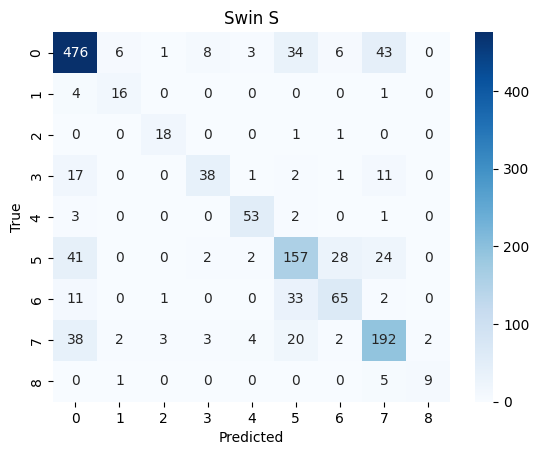

In [ ]:
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_probs = []
all_y = []

with torch.no_grad():
    for x, y in tqdm(test_loader):
        x, y = x.to(device), y.to(device).long()
        out = model(x)

        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

        all_probs.append(probs.cpu())
        all_preds.append(preds.cpu())
        all_y.append(y.cpu())


all_probs = torch.cat(all_probs).numpy()
all_preds_top3 = np.argsort(all_probs, axis=1)[:,-3:]
all_preds = torch.cat(all_preds).numpy().ravel()
all_y = torch.cat(all_y).numpy().ravel()

test_acc = accuracy_score(all_y, all_preds)
conf_mat = confusion_matrix(all_y, all_preds)

for i in range(9):
    acc = (all_preds[all_y == i] == i).sum() / (all_y == i).sum()
    print(f"accuracy on class {i}: {acc:.4f}")

print()
print(f"  Test accuracy: {test_acc:.4f}")

sns.heatmap(conf_mat, cmap="Blues", annot=True, fmt="d")
plt.title("Swin S")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

In [ ]:
def predict_image(model, image_path, transform, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():
        out = model(image)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

    return {
        "probability": probs.cpu().numpy(),
        "prediction": preds.cpu().numpy()
    }

In [ ]:
image_path = "data/test/photo_2026-03-06_16-35-59.jpg"
tr = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)
predict_image(model, image_path, tr, device)

{'probability': array([[3.7496564e-01, 6.4114247e-05, 7.0584861e-06, 4.1219970e-04,
         1.9212954e-05, 4.0217450e-01, 2.2214401e-01, 2.0747725e-04,
         5.8436149e-06]], dtype=float32),
 'prediction': array([5], dtype=int64)}

#### При большой уверенности

In [ ]:
wh = np.where((all_probs > 0.95))
pred = wh[1]
y = all_y[wh[0]]
accuracy_score(y, pred)

0.9168141592920354

In [ ]:
len(y) / len(all_y)

0.4053084648493544

In [ ]:
np.unique(y, return_counts=True)[1] / np.unique(all_y, return_counts=True)[1]

array([0.51646447, 0.52380952, 0.6       , 0.4       , 0.6779661 ,
       0.1496063 , 0.23214286, 0.39097744, 0.53333333])

In [ ]:
y_prednonzero = y[np.where(pred != 0)]
pred_prednonzero = pred[np.where(pred != 0)]
accuracy_score(y_prednonzero, pred_prednonzero)

0.9

In [ ]:
len(y_prednonzero) / len(all_y)

0.27116212338593976

In [ ]:
np.unique(y_prednonzero, return_counts=True)[1] / np.unique(all_y, return_counts=True)[1]

array([0.04679376, 0.33333333, 0.8       , 0.5       , 0.59322034,
       0.27165354, 0.41964286, 0.5037594 , 0.53333333])

#### Всякое

In [ ]:
(conf_mat[0][0] + conf_mat[1:,1:].sum()) / conf_mat.sum().sum()

0.8457675753228121

In [ ]:
conf_mat[:, 1:]

array([[  3,   2,   7,   4,  27,   8,  30,   0],
       [ 11,   0,   1,   0,   0,   0,   4,   0],
       [  0,  17,   0,   0,   2,   0,   0,   0],
       [  0,   1,  30,   0,   0,   0,  15,   0],
       [  0,   0,   0,  46,   2,   2,   3,   0],
       [  0,   1,   2,   4, 114,  44,  23,   0],
       [  0,   2,   0,   1,  23,  65,   2,   0],
       [  1,   3,   4,   1,  13,   1, 181,   1],
       [  0,   1,   0,   1,   0,   0,   2,  11]], dtype=int64)

In [ ]:
conf_mat[:, 0].sum() / conf_mat.sum().sum()

0.4232424677187948

In [ ]:
conf_mat[0, 1:].sum() / conf_mat[:, 1:].sum()

0.1256218905472637

In [ ]:
conf_mat[0, 1:].sum() / conf_mat[:, 1:].sum()

0.1256218905472637

#### За вычетом конфьюжна пересекающихся классов

In [ ]:
k = 0
for pred, true in zip(all_preds, all_y):
    if pred in [5,6] and true in [5,6]:
        k += 1
        continue
    if pred in [5,7] and true in [5,7]:
        k += 1
        continue
    if pred == true:
        k += 1
acc = k / all_y.shape[0]
print(f"light accuracy: {acc:.4f}")

light accuracy: 0.8099


In [ ]:
mat = conf_mat.copy()
wh = np.where(all_probs > 0.999)
preds = wh[1]
y = all_y[wh[0]]
k = 0
for pred, true in zip(preds, y):
    if pred in [5,6] and true in [5,6]:
        k += 1
        continue
    if pred in [5,7] and true in [5,7]:
        k += 1
        continue
    if pred == true:
        k += 1
acc = k / y.shape[0]
acc

0.9523809523809523

In [ ]:
len(y) / len(all_y)

0.23672883787661406

In [ ]:
for i in range(9):
    if conf_mat[i].sum() + conf_mat[:,i].sum() > 1. * (3 * conf_mat[i][i]):
        print(f"{i}: {conf_mat[i].sum() + conf_mat[:,i].sum() - 2 * conf_mat[i][i]} wrong, {conf_mat[i][i]} right")

1: 11 wrong, 6 right
3: 62 wrong, 36 right
6: 100 wrong, 53 right


In [ ]:
np.mean([0.8182, 0.6000, 0.8889, 0.4328, 0.2500, 0.5882, 0.6866, 0.1429, 0.2727, 0.7850,  0.4038,  0.5316,  0.3835,  0.5000])

0.5203000000000001

In [ ]:
probs_argsorted = np.argsort(all_probs, axis=1)
print(f"total objects:  {all_probs.shape[0]}")
for i in range(1, 6):
    k = 0

    mask = ((probs_argsorted[:,-i:]) == all_y[:, None]).any(axis=1)

    for j in probs_argsorted[:,-i:]:
        if 8 in j: k += 1

    print(f"top {i} accuracy:   {np.where(mask)[0].shape[0] / all_probs.shape[0]}")

    print(k)

total objects:  1394
top 1 accuracy:   0.7173601147776184
11
top 2 accuracy:   0.9110473457675753
36
top 3 accuracy:   0.9705882352941176
67
top 4 accuracy:   0.9899569583931134
103
top 5 accuracy:   0.9971305595408895
171


#### Сохранение

In [ ]:
torch.save(model.state_dict(), "models/atomic_classifier/good_classes_swin_s.pth")

In [ ]:
model = models.swin_s()
model.head = nn.Linear(model.head.in_features, 9, bias=True)
model.load_state_dict(torch.load("models/atomic_classifier/good_classes_swin_s.pth", weights_only=True))
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device);

In [ ]:
scripted = torch.jit.script(model)

In [ ]:
scripted.save("models/atomic_classifier/good_classes_swin_s_scripted.pt")

In [ ]:
def predict_image(model, image_path, transform, device):
    model.eval()

    image = Image.open(image_path).convert("RGB")
    image = transform(image)

    image = image.unsqueeze(0)
    image = image.to(device)

    with torch.no_grad():
        out = model(image)
        probs = torch.softmax(out, dim=1)
        preds = torch.argmax(probs, dim=1)

    return {
        "probability": probs.cpu().numpy(),
        "prediction": preds.cpu().numpy()
    }

In [ ]:
image_path = "data/test/2023.10.16-1697444266.9777_fili-fasad.jpg"
tr = Compose(
    [Resize((384, 384)), ToTensor(), Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])]
)
print(tr(Image.open(image_path)).shape)
#plt.imshow(tr(Image.open(image_path)).permute(1, 2, 0))
x = tr(Image.open(image_path)).unsqueeze(0).to(device)

model.eval()

with torch.no_grad():
    out = model(x)
print(out)

torch.Size([3, 384, 384])
tensor([[ 5.7346, -7.2404, -1.4457, -1.8092, -7.3249,  1.9616,  1.4107, -1.3777,
         -8.8116]], device='cuda:0')


In [ ]:
data = pd.read_csv("data/atomic_no_noise.csv")
data

,Unnamed: 0,img,attr,ID,img_num,Комментарий,Гостевая ссылка на проверку,attr_ind
0,0,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/1xT4OxIM1Yuq.jpg,"Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс",177104874,0,Череповетская ул. д.14,https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,11.0
1,1,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/KQlpdUvDLxef.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,0,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
2,2,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/YpP2fpXi5rRh.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,1,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
3,3,https://ckkb-mos.online/storage/uploads/images/10645/92192/4108578/zPBW2zALQyfq.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104876,2,", череповетская д.14 а",https://ckkb-mos.online/link/TloUtGBhN6jJdW5SZiWY35RaMl1CFPTt,9.0
4,4,https://ckkb-mos.online/storage/uploads/images/10645/92727/4108588/8AKFil1qd3J1.jpg,Нарушение содержания фасадов нежилых зданий и сооружений,177104996,0,"Д.18, школа д.12",https://ckkb-mos.online/link/s03oi5QVVPE0trTkghjJEYNUYAntJHwu,9.0
...,...,...,...,...,...,...,...,...
21350,24742,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/Wm7XbGtAoGFz.jpg,Неудовлетворительное содержание ОЛХ,233603599,4,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0
21351,24743,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/DZfvZE4vhX12.jpg,Неудовлетворительное содержание ОЛХ,233603599,5,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0
21352,24744,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/XSFn5AhMo3aA.jpg,Неудовлетворительное содержание ОЛХ,233603599,6,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0
21353,24745,https://ckkb-mos.online/storage/uploads/images/10645/147575/5458016/q5FlWpp0dDyT.jpg,Неудовлетворительное содержание ОЛХ,233603599,7,NaN,https://ckkb-mos.online/link/BDNsrWbe6nmfRGDkK68fqDkabAxIeJmW,13.0


In [ ]:
data.drop(["Unnamed: 0"], axis=1, inplace=True)

In [ ]:
data["attr"].value_counts()

attr
-                                                                                           5935
Нарушение содержания фасадов нежилых зданий и сооружений                                    5769
Нарушения в содержание дорог, МАФов, остановочных павильонов, опор УНО, опор мосгортранс    2695
Нарушения по санитарии, освещению, ТПУ, полосе отвода ж\д                                   2105
Нарушение состояния фасада жилых зданий                                                     1120
Нарушение содержания мест проведения работ по комплексному благоустройству                   825
Нарушение содержания объектов ЦОДД                                                           731
Нарушение содержания строительной площадки                                                   574
Нарушение содержания объектов гор.моста                                                      552
Нарушение содержания мест проведения работ по ремонту инженерных сооружений                  322
Наличие сухостойных дерев

In [3]:
aug_tr = Compose([
    RandomResizedCrop(
        size=(384, 384),
        scale=(0.7, 1.0),
        ratio=(0.9, 1.1)
    ),
    RandomHorizontalFlip(p=0.5),

    ColorJitter(
        brightness=0.2,
        contrast=0.3,
        saturation=0.15,
        hue=0.05
    ),

    RandomApply([
        GaussianBlur(kernel_size=3, sigma=(0.1, 0.7))
    ], p=0.2),

    RandomApply([
        RandomRotation(
            degrees=10,
            interpolation=InterpolationMode.BICUBIC
        )
    ], p=0.3),

    RandomApply([
        RandomPerspective(
            distortion_scale=0.15,
            p=1.0
        )
    ], p=0.2),
])

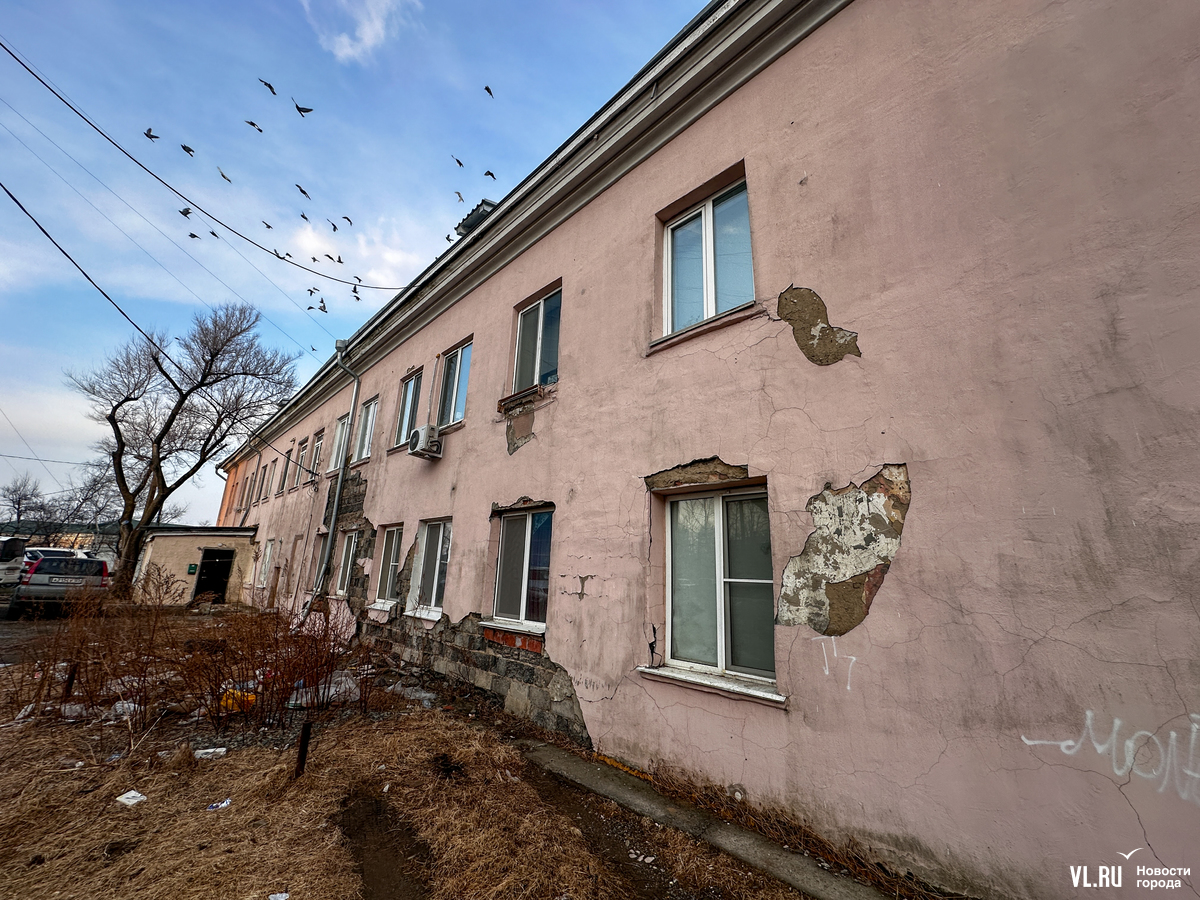

In [3]:
Image.open("data/test/1744170596144_default.jpg")

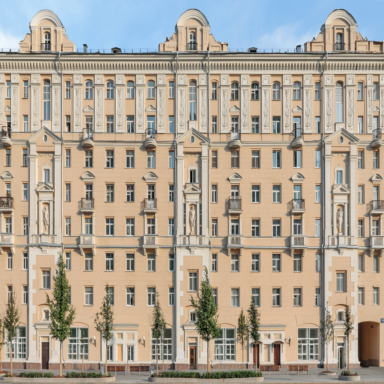

In [5]:
image = Image.open("1619707359159344438.jpg")
aug_tr(image)